# Pipeline metagenómico 

En este primer pipeline, se presenta la manera en la cual se pueden descargar los datos crudos de la base de datos del ENA (https://www.ebi.ac.uk/ena/browser/view/PRJEB11755), procesarlos, e identificar genes y dominios funcionales de la muestra seleccionada. Luego, usamos el repositorio público de CARD (https://card.mcmaster.ca/) para identificar los genes de resistencias presentes en la muestra seleccionada. El código presente es para muestras individuales, pero en el notebook 3, lo adaptamos para analizar múltiples muestras de forma cíclica, obtener todos los genes de resistencia, y analizar según categoría y frecuencia de presencia de dichos genes de resistencia. Los datos obtenidos de este pipeline serán el punto de partida de obtención de datos para construir un algoritmo de aprendizaje de máquina.


## 0. Configuración y utilidades

In [3]:
import os, subprocess, hashlib, shutil
from pathlib import Path
import pandas as pd

# ---- Parámetros (edita aquí) ----
RUN       = "ERR1135202"    # run_accession de ENA a procesar
SUBSAMPLE = 1_000_000        # nº de pares a submuestrear (ensayo rápido)
THREADS   = 4                # hilos de CPU
SEED      = 100              # semilla fija -> submuestreo reproducible

# ---- Carpetas de trabajo (se crean si no existen) ----
RAW_DIR  = Path(f"raw/{RUN}")      # FASTQ descargados
WORK_DIR = Path(f"work/{RUN}")     # intermedios
OUT_DIR  = Path(f"results/{RUN}")  # salida final
for d in (RAW_DIR, WORK_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

def sh(cmd):
    """Ejecuta un comando de shell, muestra su salida y aborta si falla."""
    print(f"$ {cmd}")
    r = subprocess.run(cmd, shell=True, text=True,
                       stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    if r.stdout:
        print(r.stdout)
    if r.returncode != 0:
        raise RuntimeError(f"Falló (código {r.returncode}): {cmd}")
    return r.stdout

print("Entorno listo. Muestra a procesar:", RUN)

Entorno listo. Muestra a procesar: ERR1135202


## 1. Resolver URLs y checksums desde la API de ENA

En vez de adivinar rutas FTP, le preguntamos a ENA por los archivos de este run y sus MD5. `pandas` puede leer la respuesta directamente desde la URL.

In [4]:
ena_url = (
    "https://www.ebi.ac.uk/ena/portal/api/filereport"
    f"?accession={RUN}&result=read_run"
    "&fields=fastq_ftp,fastq_md5&format=tsv"
)
ena = pd.read_csv(ena_url, sep="\t")
ena

,run_accession,fastq_ftp,fastq_md5
0,ERR1135202,ftp.sra.ebi.ac.uk/vol1/fastq/ERR113/002/ERR113...,e70de4a370c5b47d27dcf3d922493526;16f246198b303...


In [5]:
# Cada campo trae "archivo_1;archivo_2" (paired-end). Los separamos.
ftp = ena.loc[0, "fastq_ftp"].split(";")
md5 = ena.loc[0, "fastq_md5"].split(";")
url1, url2 = "https://" + ftp[0], "https://" + ftp[1]
r1 = RAW_DIR / f"{RUN}_1.fastq.gz"
r2 = RAW_DIR / f"{RUN}_2.fastq.gz"
print(url1)
print(url2)

https://ftp.sra.ebi.ac.uk/vol1/fastq/ERR113/002/ERR1135202/ERR1135202_1.fastq.gz
https://ftp.sra.ebi.ac.uk/vol1/fastq/ERR113/002/ERR1135202/ERR1135202_2.fastq.gz


In [15]:
# ============================================================
#  Asegurar la base de datos CARD (idempotente y portable)
#  Estrategia en cascada: si ya está cargada la usa; si no,
#  la reutiliza de data/; y si tampoco, la descarga desde cero.
# ============================================================
from pathlib import Path

CARD_URL = "https://card.mcmaster.ca/latest/data"

if Path("localDB/card.json").exists():
    print("CARD ya está cargada en localDB/, no hago nada.")

else:
    if Path("card.json").exists():
        print("Encontré card.json en la raíz; la cargo.")
    elif Path("data/card.json").exists():
        print("Reutilizo la card.json que ya tienes en data/.")
        sh("cp data/card.json card.json")
    else:
        print("No hay CARD en ningún sitio; la descargo (una sola vez)...")
        sh(f"wget -q {CARD_URL} -O card_data.tar.bz2")
        sh("tar -xjf card_data.tar.bz2 ./card.json")

    # Cargar la base en localDB/ del directorio actual
    sh("rgi load --card_json card.json --local")

# Verificación final: si esto falla, algo no cuadró
assert Path("localDB/card.json").exists(), "CARD no quedó cargada; revisa los pasos de arriba."
print("Base CARD lista en:", Path("localDB").resolve())

Reutilizo la card.json que ya tienes en data/.
$ cp data/card.json card.json
$ rgi load --card_json card.json --local
Base CARD lista en: /home/jujgomezru/unal/aprendizajeDeMaquina/proyectoFinalML/localDB


In [27]:
# ============================================================
#  Preparar BLAST REMOTO (cero descargas: usa los servidores del NCBI)
#  Solo requiere biopython, que ya está en tu entorno.
# ============================================================
from Bio.Blast import NCBIWWW, NCBIXML
import time, re

# El NCBI pide identificarte para uso remoto (evita bloqueos). Pon tu correo real:
NCBIWWW.email = "jujgomezru@unal.edu.co"

def blast_remoto(fasta_str, program="blastn", db="nt", hitlist=1, max_reintentos=3):
    ultimo = None
    for intento in range(1, max_reintentos + 1):
        try:
            handle = NCBIWWW.qblast(program, db, fasta_str, hitlist_size=hitlist, megablast=True)
            return list(NCBIXML.parse(handle))
        except Exception as e:
            ultimo = e
            print(f"  Intento {intento}/{max_reintentos} -> {type(e).__name__}: {e}")
            if intento < max_reintentos:
                time.sleep(20)
    raise RuntimeError(f"BLAST falló tras {max_reintentos} intentos: "
                       f"{type(ultimo).__name__}: {ultimo}") from ultimo

def organismo_de_descripcion(desc):
    """Extrae 'Género especie' del mejor hit, de forma conservadora."""
    desc = desc.replace("[", "").replace("]", "")
    desc = re.sub(r"^(PREDICTED:|UNVERIFIED:|MAG:|TPA:|TPA_asm:)\s*", "", desc).strip()
    palabras = desc.split()
    if not palabras:
        return None
    if palabras[0].lower() in ("uncultured", "unidentified", "bacterium", "synthetic"):
        return palabras[0].lower()                    # match de baja resolución
    if len(palabras) >= 2 and palabras[1][0].islower():
        return f"{palabras[0]} {palabras[1]}"         # Género especie
    return palabras[0]                                # solo género

print("BLAST remoto listo. Recuerda poner tu correo arriba.")

BLAST remoto listo. Recuerda poner tu correo arriba.


## 2. Descargar (reanudable) y verificar integridad con MD5

`wget -c` reanuda si la descarga se corta. Después comprobamos el MD5 en Python; si no coincide, abortamos (una descarga corrupta causa errores fantasma más adelante).

In [8]:
import time, urllib.request, urllib.error

def _human(n):
    for u in ["B", "KB", "MB", "GB"]:
        if n < 1024:
            return f"{n:.1f}{u}"
        n /= 1024
    return f"{n:.1f}TB"

def md5sum(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def download(url, out, want_md5, chunk=1 << 18, max_retries=1000):
    """Descarga robusta: progreso, reanudación tras cortes y verificación MD5."""
    out = Path(out)
    if out.exists() and md5sum(out) == want_md5:
        print(f"Ya existe y el MD5 coincide: {out.name}")
        return
    attempt = 0
    last_print = 0.0
    while True:
        existing = out.stat().st_size if out.exists() else 0     # bytes ya bajados -> reanudar
        headers = {"Range": f"bytes={existing}-"} if existing else {}
        try:
            with urllib.request.urlopen(urllib.request.Request(url, headers=headers), timeout=120) as resp:
                if existing and getattr(resp, "status", 200) == 206:      # el servidor reanuda
                    mode = "ab"
                    total = existing + int(resp.headers.get("Content-Length", 0))
                else:                                                     # empieza de cero
                    existing, mode = 0, "wb"
                    total = int(resp.headers.get("Content-Length", 0))
                done, t0 = existing, time.time()
                with open(out, mode) as f:
                    while True:
                        block = resp.read(chunk)
                        if not block:
                            break
                        f.write(block)
                        done += len(block)
                        now = time.time()
                        if now - last_print >= 0.2 or (total and done >= total):   # refresca ~5 veces/s
                            last_print = now
                            el = now - t0
                            spd = (done - existing) / el if el > 0 else 0
                            pct = (done / total * 100) if total else 0
                            eta = (total - done) / spd if spd > 0 else 0
                            print(f"\r  {out.name}: {pct:5.1f}%  {_human(done)}/{_human(total)}  "
                                  f"{_human(spd)}/s  ETA {int(eta//60)}m{int(eta%60):02d}s   ",
                                  end="", flush=True)
            # CLAVE: si el read terminó pero no llegamos al total, NO está completo -> reanudar
            if total and done < total:
                raise IOError(f"conexión cerrada antes de tiempo: {_human(done)}/{_human(total)}")
            print()
            break
        except urllib.error.HTTPError as e:
            if e.code == 416:                     # el archivo local sobra/está mal -> reiniciar limpio
                print(f"\n  Rango inválido; reinicio {out.name} desde cero.")
                out.unlink(missing_ok=True)
                continue
            raise
        except Exception as e:                    # timeout / cierre / broken pipe -> reintenta y reanuda
            attempt += 1
            if attempt > max_retries:
                raise
            print(f"\n  Interrumpido ({e}); reintentando en 5s [{attempt}]...", flush=True)
            time.sleep(5)
    got = md5sum(out)
    if got != want_md5:
        raise RuntimeError(f"MD5 no coincide para {out.name}: {got} != {want_md5}")
    print(f"  Descarga verificada: {out.name}")

download(url1, r1, md5[0])
download(url2, r2, md5[1])

Ya existe y el MD5 coincide: ERR1135202_1.fastq.gz
  ERR1135202_2.fastq.gz:  35.2%  602.0MB/1.7GB  125.2KB/s  ETA 150m59s   
  Interrumpido (conexión cerrada antes de tiempo: 602.1MB/1.7GB); reintentando en 5s [1]...
  ERR1135202_2.fastq.gz:  74.9%  1.2GB/1.7GB  1.7MB/s  ETA 4m17s         
  Interrumpido (conexión cerrada antes de tiempo: 1.3GB/1.7GB); reintentando en 5s [2]...
  ERR1135202_2.fastq.gz: 100.0%  1.7GB/1.7GB  1.0MB/s  ETA 0m00s      
  Descarga verificada: ERR1135202_2.fastq.gz


## 3. Control de calidad y recorte de adaptadores (fastp)

Genera además un reporte visual `.html` que puedes abrir para ver el antes/después.

In [9]:
clean1 = WORK_DIR / "clean_1.fastq.gz"
clean2 = WORK_DIR / "clean_2.fastq.gz"
if clean1.exists() and clean2.exists():
    print("QC ya realizado, se omite")
else:
    sh(f"fastp -i {r1} -I {r2} -o {clean1} -O {clean2} "
       f"-w {THREADS} -h {OUT_DIR}/{RUN}_fastp.html -j {OUT_DIR}/{RUN}_fastp.json")

$ fastp -i raw/ERR1135202/ERR1135202_1.fastq.gz -I raw/ERR1135202/ERR1135202_2.fastq.gz -o work/ERR1135202/clean_1.fastq.gz -O work/ERR1135202/clean_2.fastq.gz -w 4 -h results/ERR1135202/ERR1135202_fastp.html -j results/ERR1135202/ERR1135202_fastp.json
Read1 before filtering:
total reads: 23520302
total bases: 2213684204
Q20 bases: 2195826506(99.1933%)
Q30 bases: 2117780548(95.6677%)
Q40 bases: 796456593(35.9788%)

Read2 before filtering:
total reads: 23520302
total bases: 2101282472
Q20 bases: 2074379438(98.7197%)
Q30 bases: 1981460398(94.2977%)
Q40 bases: 760528842(36.1936%)

Read1 after filtering:
total reads: 23519849
total bases: 2213213766
Q20 bases: 2195366035(99.1936%)
Q30 bases: 2117358985(95.669%)
Q40 bases: 796370814(35.9826%)

Read2 after filtering:
total reads: 23519849
total bases: 2100896312
Q20 bases: 2074018541(98.7207%)
Q30 bases: 1981149689(94.3002%)
Q40 bases: 760474706(36.1976%)

Filtering result:
reads passed filter: 47039698
reads failed due to low quality: 906
r

## 4. Submuestreo reproducible (seqtk)

Tomamos una fracción al azar con la **misma semilla** en ambos pares, para que las lecturas sigan emparejadas. Esto hace el ensayo rápido; para la muestra completa, sube `SUBSAMPLE` o sáltate este paso.

In [10]:
sub1 = WORK_DIR / "sub_1.fastq"
sub2 = WORK_DIR / "sub_2.fastq"
if sub1.exists() and sub2.exists():
    print("Submuestreo ya realizado, se omite")
else:
    sh(f"seqtk sample -s{SEED} {clean1} {SUBSAMPLE} > {sub1}")
    sh(f"seqtk sample -s{SEED} {clean2} {SUBSAMPLE} > {sub2}")

$ seqtk sample -s100 work/ERR1135202/clean_1.fastq.gz 1000000 > work/ERR1135202/sub_1.fastq
$ seqtk sample -s100 work/ERR1135202/clean_2.fastq.gz 1000000 > work/ERR1135202/sub_2.fastq


## 5. Ensamblado (MEGAHIT)

Reconstruye contigs a partir de las lecturas. **Este paso es el más lento** (varios minutos); en el notebook su salida aparecerá cuando termine, no en vivo. Ten paciencia.

In [11]:
import subprocess, time

def sh_live(cmd):
    """Ejecuta un comando mostrando su salida EN VIVO, con el tiempo transcurrido."""
    print(f"$ {cmd}\n")
    t0 = time.time()
    proc = subprocess.Popen(cmd, shell=True, text=True, bufsize=1,
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    for line in proc.stdout:
        el = time.time() - t0
        print(f"[{int(el//60):>2}m{int(el%60):02d}s] {line}", end="", flush=True)
    proc.wait()
    el = time.time() - t0
    if proc.returncode != 0:
        raise RuntimeError(f"Falló (código {proc.returncode}) tras {int(el)}s: {cmd}")
    print(f"\nCompletado en {int(el//60)}m{int(el%60):02d}s")

contigs = WORK_DIR / "megahit_out" / "final.contigs.fa"
if contigs.exists():
    print("Ensamblado ya existe, se omite")
else:
    shutil.rmtree(WORK_DIR / "megahit_out", ignore_errors=True)  # MEGAHIT exige que NO exista
    sh_live(f"megahit -1 {sub1} -2 {sub2} -t {THREADS} -o {WORK_DIR}/megahit_out")

$ megahit -1 work/ERR1135202/sub_1.fastq -2 work/ERR1135202/sub_2.fastq -t 4 -o work/ERR1135202/megahit_out

[ 0m00s] 2026-07-14 17:51:51 - MEGAHIT v1.2.9
[ 0m00s] 2026-07-14 17:51:51 - Using megahit_core with POPCNT and BMI2 support
[ 0m00s] 2026-07-14 17:51:51 - Convert reads to binary library
[ 0m02s] 2026-07-14 17:51:53 - b'INFO  sequence/io/sequence_lib.cpp  :   75 - Lib 0 (/home/jujgomezru/unal/aprendizajeDeMaquina/proyectoFinalML/work/ERR1135202/sub_1.fastq,/home/jujgomezru/unal/aprendizajeDeMaquina/proyectoFinalML/work/ERR1135202/sub_2.fastq): pe, 2000000 reads, 95 max length'
[ 0m02s] 2026-07-14 17:51:53 - b'INFO  utils/utils.h                 :  152 - Real: 2.3632\tuser: 1.2954\tsys: 0.9737\tmaxrss: 97952'
[ 0m02s] 2026-07-14 17:51:53 - k-max reset to: 99 
[ 0m02s] 2026-07-14 17:51:53 - Start assembly. Number of CPU threads 4 
[ 0m02s] 2026-07-14 17:51:53 - k list: 21,29,39,59,79,99 
[ 0m02s] 2026-07-14 17:51:53 - Memory used: 7127562240
[ 0m02s] 2026-07-14 17:51:53 - Extract

In [30]:
import pandas as pd
from Bio import SeqIO

# IDs reales de tus contigs (del ensamblado que ya existe)
asm_ids = {r.id for r in SeqIO.parse(str(contigs), "fasta")}
print(f"Contigs en el ensamblado: {len(asm_ids)}")   # sanity: debe ser > 0

rgi = pd.read_csv(f"{rgi_out}.txt", sep="\t")

def contig_de_orf(orf):
    """Deduce el contig real del ORF_ID de RGI, anclándose en los IDs del ensamblado."""
    orf = str(orf).split()[0]
    if orf in asm_ids:
        return orf
    partes = orf.split("_")
    for corte in range(len(partes) - 1, 0, -1):
        cand = "_".join(partes[:corte])
        if cand in asm_ids:
            return cand
    return None

rgi["contig_asm"] = rgi["ORF_ID"].map(contig_de_orf)
matched = rgi["contig_asm"].notna().sum()
print(f"Filas de RGI emparejadas a un contig real: {matched}/{len(rgi)}")

wanted = set(rgi["contig_asm"].dropna())
recs = [r for r in SeqIO.parse(str(contigs), "fasta") if r.id in wanted]
print(f"Contigs con ARG extraídos: {len(recs)}")

Contigs en el ensamblado: 6365
Filas de RGI emparejadas a un contig real: 8/8
Contigs con ARG extraídos: 8


In [31]:
import pandas as pd

filas = []
for i, r in enumerate(recs, 1):
    print(f"[{i}/{len(recs)}] BLAST de {r.id} ...", flush=True)
    try:
        registros = blast_remoto(f">{r.id}\n{r.seq}\n")   # un contig por envío
        rec = registros[0]
        if rec.alignments:
            top = rec.alignments[0]; hsp = top.hsps[0]
            pid = 100 * hsp.identities / hsp.align_length
            filas.append({"contig": r.id,
                          "taxon": organismo_de_descripcion(top.hit_def),
                          "identidad_%": round(pid, 1),
                          "descripcion": top.hit_def[:70]})
        else:
            filas.append({"contig": r.id, "taxon": None, "identidad_%": None, "descripcion": "sin hits"})
    except Exception as e:
        print(f"    Falló {r.id}: {e}")
        filas.append({"contig": r.id, "taxon": None, "identidad_%": None, "descripcion": f"error: {e}"})

blast_df = pd.DataFrame(filas)
contig_to_species = dict(zip(blast_df["contig"], blast_df["taxon"]))
blast_df

[1/8] BLAST de k99_264 ...
[2/8] BLAST de k99_5459 ...
[3/8] BLAST de k99_5463 ...
[4/8] BLAST de k99_2568 ...
[5/8] BLAST de k99_2618 ...
[6/8] BLAST de k99_1321 ...
[7/8] BLAST de k99_4448 ...
[8/8] BLAST de k99_4599 ...


,contig,taxon,identidad_%,descripcion
0,k99_264,Fusobacterium sp.,95.7,Fusobacterium sp. P6 Po strain Fusobacterium g...
1,k99_5459,Prevotella communis,98.5,"Prevotella communis strain E13-3 chromosome, c..."
2,k99_5463,Alistipes communis,98.7,Alistipes communis strain CIP112231 chromosome...
3,k99_2568,NaN,NaN,sin hits
4,k99_2618,Clostridiales bacterium,99.4,"Clostridiales bacterium CCNA10 DNA, complete g..."
5,k99_1321,uncultured,99.8,Uncultured bacterium IN-06 clone IN-06
6,k99_4448,Barnesiella intestinihominis,100.0,Barnesiella intestinihominis strain SFAD78 chr...
7,k99_4599,Eubacterium sp.,100.0,"Eubacterium sp. MSJ-33 chromosome, complete ge..."


In [1]:
import time, urllib.request, urllib.error, threading
from pathlib import Path

def _human(n):
    for u in ["B", "KB", "MB", "GB", "TB"]:
        if n < 1024:
            return f"{n:.1f}{u}"
        n /= 1024
    return f"{n:.1f}PB"

def descargar(url, out, chunk=1 << 15, timeout=30, max_retries=1000):
    """Descarga con LATIDO en hilo aparte: siempre muestra fase, tiempo y bytes, aunque esté esperando."""
    out = Path(out)
    st = {"done": 0, "total": 0, "fase": "conectando", "t0": time.time(), "vivo": True}

    def latido():
        while st["vivo"]:
            time.sleep(1)
            if not st["vivo"]:
                break
            el = int(time.time() - st["t0"])
            if st["total"]:
                pct = st["done"] / st["total"] * 100
                print(f"\r  [{el:>3}s] {st['fase']}: {pct:4.1f}%  {_human(st['done'])}/{_human(st['total'])}     ", end="", flush=True)
            else:
                print(f"\r  [{el:>3}s] {st['fase']}: {_human(st['done'])} descargado     ", end="", flush=True)

    hb = threading.Thread(target=latido, daemon=True); hb.start()
    attempt = 0
    try:
        while True:
            existing = out.stat().st_size if out.exists() else 0
            headers = {"Range": f"bytes={existing}-"} if existing else {}
            st["fase"] = "conectando"; st["t0"] = time.time()
            try:
                with urllib.request.urlopen(urllib.request.Request(url, headers=headers), timeout=timeout) as resp:
                    if existing and getattr(resp, "status", 200) == 206:
                        mode = "ab"; total = existing + int(resp.headers.get("Content-Length", 0))
                    else:
                        existing, mode = 0, "wb"; total = int(resp.headers.get("Content-Length", 0))
                    st["total"] = total; st["done"] = existing; st["fase"] = "descargando"; done = existing
                    with open(out, mode) as f:
                        while True:
                            block = resp.read1(chunk)
                            if not block:
                                break
                            f.write(block); done += len(block); st["done"] = done
                if total and done < total:
                    raise IOError(f"conexión cerrada antes de tiempo: {_human(done)}/{_human(total)}")
                st["vivo"] = False
                print(f"\n  Descarga completa: {out.name} ({_human(out.stat().st_size)})")
                return
            except urllib.error.HTTPError as e:
                if e.code == 416:
                    st["vivo"] = False; print(f"\n  {out.name} ya está completo."); return
                raise
            except Exception as e:
                attempt += 1
                if attempt > max_retries:
                    raise
                print(f"\n  Interrumpido ({type(e).__name__}: {e}); reintentando [{attempt}]...", flush=True)
                time.sleep(2)
    finally:
        st["vivo"] = False

# --- Descargar la anotación de taxonomía del catálogo ---
BASE   = "https://ftp.cngb.org/pub/SciRAID/Microbiome/pig/"
NR_TAX = BASE + "GeneAnnotation/pigGut.GeneCatalog.NR-tax.annotation.gz"

Path("catalog").mkdir(exist_ok=True)
descargar(NR_TAX, "catalog/pig_NR_tax.annotation.gz")

  [  8s] descargando: 85.5%  19.8MB/23.1MB      
  Descarga completa: pig_NR_tax.annotation.gz (23.1MB)


In [3]:
import pandas as pd
from collections import Counter

path = "catalog/pig_NR_tax.annotation.gz"

# El archivo NO tiene encabezado: le damos nombres nosotros
COLS = ["gene_id", "confianza", "taxon", "rango", "linaje", "rangos_linaje"]

# Censo por trozos (son millones de genes), contando taxón y su rango
conteo_taxon = Counter()
conteo_rango = Counter()
total_genes = 0
for chunk in pd.read_csv(path, sep="\t", compression="gzip", header=None,
                         names=COLS, usecols=["taxon", "rango"], chunksize=500_000):
    total_genes += len(chunk)
    conteo_taxon.update(chunk["taxon"].dropna().astype(str))
    conteo_rango.update(chunk["rango"].dropna().astype(str))

print(f"Genes totales en el catálogo: {total_genes:,}")
print(f"Taxones distintos: {len(conteo_taxon):,}")

print("\n¿A qué rango llega la asignación? (aquí se ve cuántos alcanzan 'species')")
for rango, n in conteo_rango.most_common():
    print(f"  {rango:12s}: {n:>10,}  ({100*n/total_genes:.1f}%)")

print("\n¿Cubre los géneros esperados por el resistoma de tu muestra?")
for g in ["Bacteroides", "Prevotella", "Clostridium", "Lactobacillus", "Escherichia"]:
    hits = sum(v for k, v in conteo_taxon.items() if g.lower() in k.lower())
    print(f"  {g:14s}: {'sí' if hits else 'no'} ({hits:,} genes)")

print("\nTop 15 taxones del catálogo:")
for tax, n in conteo_taxon.most_common(15):
    print(f"  {n:>9,}  {tax}")

Genes totales en el catálogo: 3,903,585
Taxones distintos: 996

¿A qué rango llega la asignación? (aquí se ve cuántos alcanzan 'species')
  order       :  1,003,317  (25.7%)
  phylum      :    902,081  (23.1%)
  superkingdom:    731,294  (18.7%)
  genus       :    562,428  (14.4%)
  family      :    446,011  (11.4%)
  class       :    233,103  (6.0%)
  species     :     25,336  (0.6%)
  subphylum   :         15  (0.0%)

¿Cubre los géneros esperados por el resistoma de tu muestra?
  Bacteroides   : sí (62,715 genes)
  Prevotella    : sí (186,701 genes)
  Clostridium   : sí (60,388 genes)
  Lactobacillus : sí (19,680 genes)
  Escherichia   : sí (7,920 genes)

Top 15 taxones del catálogo:
    708,023  Bacteria
    682,689  Clostridiales
    650,054  Firmicutes
    262,951  Bacteroidales
    166,551  Bacteroidetes
    148,176  Lachnospiraceae
    144,914  Prevotella
    117,832  Clostridia
     98,429  Ruminococcaceae
     60,707  Bacteroides
     59,862  Clostridium
     54,428  Ruminococ

## 6. Predicción de genes (Prodigal)

Encuentra los genes dentro de los contigs y los guarda como proteínas (`.faa`) y nucleótidos (`.fna`).

In [13]:
genes_faa = WORK_DIR / "genes.faa"
genes_fna = WORK_DIR / "genes.fna"
if not genes_faa.exists():
    sh(f"prodigal -i {contigs} -a {genes_faa} -d {genes_fna} -p meta -q")

n_genes = int(subprocess.run(f"grep -c '>' {genes_faa}", shell=True,
                             text=True, capture_output=True).stdout or 0)
print(f"Genes predichos: {n_genes}")

Genes predichos: 8264


## 7. Detección de genes de resistencia (RGI contra CARD)

Usamos las proteínas (`-t protein`) porque ya las predijo Prodigal. Requiere la base CARD cargada localmente.

In [16]:
if not (Path("localDB/card.json").exists() or Path("card.json").exists()):
    raise RuntimeError(
        "No encuentro la base CARD local. Corre antes en esta carpeta:\n"
        "  rgi load --card_json card.json --local"
    )

rgi_out = OUT_DIR / f"rgi_{RUN}"
sh(f"rgi main -i {genes_faa} -o {rgi_out} -t protein -a DIAMOND --local --clean")

$ rgi main -i work/ERR1135202/genes.faa -o results/ERR1135202/rgi_ERR1135202 -t protein -a DIAMOND --local --clean
WARNING 2026-07-14 18:05:10,274 : (Database.py::write_fasta_from_json::122) : No snp for model (2252, LpxD). RGI will omit this model and keep running.
WARNING 2026-07-14 18:05:10,275 : (Database.py::write_fasta_from_json::122) : No snp for model (2313, Enterococcus faecalis YvlB with mutation conferring daptomycin resistance). RGI will omit this model and keep running.
WARNING 2026-07-14 18:05:10,275 : (Database.py::write_fasta_from_json::122) : No snp for model (2312, Enterococcus faecalis drmA with mutation conferring daptomycin resistance). RGI will omit this model and keep running.
WARNING 2026-07-14 18:05:10,275 : (Database.py::write_fasta_from_json::122) : No snp for model (2302, Enterococcus faecalis gdpD with mutation conferring daptomycin resistance). RGI will omit this model and keep running.
WARNING 2026-07-14 18:05:10,276 : (Database.py::write_fasta_from_json:

'WARNING 2026-07-14 18:05:10,274 : (Database.py::write_fasta_from_json::122) : No snp for model (2252, LpxD). RGI will omit this model and keep running.\nWARNING 2026-07-14 18:05:10,275 : (Database.py::write_fasta_from_json::122) : No snp for model (2313, Enterococcus faecalis YvlB with mutation conferring daptomycin resistance). RGI will omit this model and keep running.\nWARNING 2026-07-14 18:05:10,275 : (Database.py::write_fasta_from_json::122) : No snp for model (2312, Enterococcus faecalis drmA with mutation conferring daptomycin resistance). RGI will omit this model and keep running.\nWARNING 2026-07-14 18:05:10,275 : (Database.py::write_fasta_from_json::122) : No snp for model (2302, Enterococcus faecalis gdpD with mutation conferring daptomycin resistance). RGI will omit this model and keep running.\nWARNING 2026-07-14 18:05:10,276 : (Database.py::write_fasta_from_json::122) : No snp for model (3717, Mycobacterium tuberculosis Rv1667 mutations confer resistance to pyrazinamide)

## 8. Cargar y visualizar el resistoma

Aquí es donde el notebook brilla: leemos la tabla de RGI con pandas y la resumimos. Estas columnas son las que alimentarán después el modelo (familia de ARG, clase de antibiótico, mecanismo, y el identificador ARO).

In [17]:
rgi = pd.read_csv(f"{rgi_out}.txt", sep="\t")
print(f"Genes de resistencia detectados: {len(rgi)}")
print("Por tipo de acierto (Cut_Off):")
print(rgi["Cut_Off"].value_counts())

rgi[["Best_Hit_ARO", "Drug Class", "Resistance Mechanism", "AMR Gene Family"]]

Genes de resistencia detectados: 8
Por tipo de acierto (Cut_Off):
Cut_Off
Strict    8
Name: count, dtype: int64


,Best_Hit_ARO,Drug Class,Resistance Mechanism,AMR Gene Family
0,lnuC,lincosamide antibiotic,antibiotic inactivation,lincosamide nucleotidyltransferase (LNU)
1,tet(Q),tetracycline antibiotic,antibiotic target protection,tetracycline-resistant ribosomal protection pr...
2,tet(Q),tetracycline antibiotic,antibiotic target protection,tetracycline-resistant ribosomal protection pr...
3,nimJ,nitroimidazole antibiotic,antibiotic inactivation,nitroimidazole reductase
4,tet(W),tetracycline antibiotic,antibiotic target protection,tetracycline-resistant ribosomal protection pr...
5,tet(O),tetracycline antibiotic,antibiotic target protection,tetracycline-resistant ribosomal protection pr...
6,tet(Q),tetracycline antibiotic,antibiotic target protection,tetracycline-resistant ribosomal protection pr...
7,tet(O),tetracycline antibiotic,antibiotic target protection,tetracycline-resistant ribosomal protection pr...


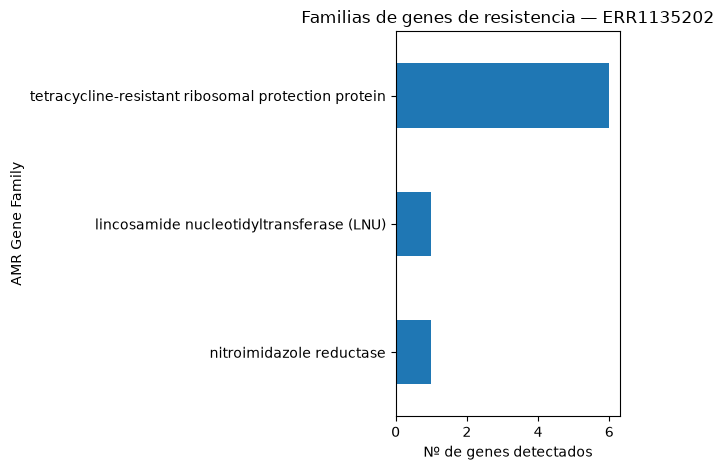

In [18]:
import matplotlib.pyplot as plt

fam = rgi["AMR Gene Family"].value_counts()
ax = fam.plot(kind="barh")
ax.invert_yaxis()
plt.xlabel("Nº de genes detectados")
plt.title(f"Familias de genes de resistencia — {RUN}")
plt.tight_layout()
plt.show()

---
**Siguiente paso.** Este resistoma es el lado de la *etiqueta* para el modelo (qué familias de ARG hay). Lo que falta es el *quién*: a qué bacteria pertenece cada gen (asignación taxonómica), para luego cruzarlo con los rasgos de BacDive. Ese es el puente hacia la tabla de entrenamiento.

In [4]:
import gzip, pandas as pd

ardb_path  = "catalog/pig_ardb.annotation.gz"
nrtax_path = "catalog/pig_NR_tax.annotation.gz"
NRTAX_COLS = ["gene_id", "confianza", "taxon", "rango", "linaje", "rangos_linaje"]

# 1) Ver la estructura del ardb (no conocemos sus columnas aún)
print("=== Primeras líneas de ardb ===")
with gzip.open(ardb_path, "rt") as f:
    for i, line in enumerate(f):
        print(line.rstrip()[:200])
        if i >= 3:
            break

# 2) Cargar ardb completo (es pequeño: solo genes de resistencia)
ardb = pd.read_csv(ardb_path, sep="\t", compression="gzip", header=None).rename(columns={0: "gene_id"})
print(f"\nGenes de resistencia en el catálogo (ardb): {len(ardb):,}  |  columnas: {ardb.shape[1]}")
print(ardb.head())
ardb_ids = set(ardb["gene_id"])

# 3) Recorrer NR-tax por trozos y quedarnos solo con los genes que están en ardb
trozos = []
for chunk in pd.read_csv(nrtax_path, sep="\t", compression="gzip", header=None,
                         names=NRTAX_COLS, usecols=["gene_id", "taxon", "rango"], chunksize=500_000):
    trozos.append(chunk[chunk["gene_id"].isin(ardb_ids)])
tax_res = pd.concat(trozos, ignore_index=True)
print(f"\nGenes de resistencia con taxonomía asignada: {len(tax_res):,} de {len(ardb):,}")

# 4) LA RESPUESTA: ¿qué taxones portan genes de resistencia?
print("\nTop 20 taxones portadores de genes de resistencia:")
print(tax_res["taxon"].value_counts().head(20))

print("\n¿A qué rango llega la taxonomía de esos genes?")
print(tax_res["rango"].value_counts())

# 5) Tabla combinada gen -> taxón -> resistencia (para inspeccionar)
portadores = tax_res.merge(ardb, on="gene_id", how="left")
portadores.head(20)

=== Primeras líneas de ardb ===
PIG-078_GL0207938	99.48	0.0	ardb_2763	tetx	80	--	tetracycline	tet_mod	NADP-requiring oxidoreductase, an enzyme that can modify tetracycline. Mechanism detail unknown.
PIG-079_GL0087434	61.21	3e-90	ardb_320	baca	30	--	bacitracin	baca	Undecaprenyl pyrophosphate phosphatase, which consists in the sequestration of Undecaprenyl pyrophosphate.
PIG-079_GL0202056	98.78	0.0	ardb_1439	tet40	80	--	tetracycline	tet_efflux	Major facilitator superfamily transporter, tetracycline efflux pump.
PIG-080_GL0048541	77.82	9e-113	ardb_574	baca	30	--	bacitracin	baca	Undecaprenyl pyrophosphate phosphatase, which consists in the sequestration of Undecaprenyl pyrophosphate.

Genes de resistencia en el catálogo (ardb): 534  |  columnas: 10
             gene_id      1              2          3      4   5   6  \
0  PIG-078_GL0207938  99.48   0.000000e+00  ardb_2763   tetx  80  --   
1  PIG-079_GL0087434  61.21   3.000000e-90   ardb_320   baca  30  --   
2  PIG-079_GL0202056  98.78  

,gene_id,taxon,rango,1,2,3,4,5,6,7,8,9
0,PIG_149_GL0226847,Burkholderiales,order,54.37,3.000000e-77,ardb_344,baca,30,--,bacitracin,baca,"Undecaprenyl pyrophosphate phosphatase, which ..."
1,PIG_111_GL0013236,Eubacteriaceae,family,79.79,3.000000e-131,ardb_345,baca,30,--,bacitracin,baca,"Undecaprenyl pyrophosphate phosphatase, which ..."
2,PIG_151_GL0211436,Firmicutes,phylum,53.43,2.000000e-82,ardb_2980,baca,30,--,bacitracin,baca,"Undecaprenyl pyrophosphate phosphatase, which ..."
3,PIG_151_GL0235858,Bacteria,superkingdom,54.00,2.000000e-69,ardb_2198,baca,30,--,bacitracin,baca,"Undecaprenyl pyrophosphate phosphatase, which ..."
4,PIG_151_GL0341429,Firmicutes,phylum,66.43,1.000000e-104,ardb_345,baca,30,--,bacitracin,baca,"Undecaprenyl pyrophosphate phosphatase, which ..."
5,PIG_152_GL0242659,Firmicutes,phylum,86.71,1.000000e-86,ardb_1956,vatb,80,--,streptogramin_a,vat,"Virginiamycin A acetyltransferase, which can i..."
6,PIG_155_GL0009711,Prevotella,genus,98.24,0.000000e+00,ardb_533,tet37,80,--,tetracycline,tet_flavo,Flavoproteins. Mechanism detail unknown. Only ...
7,PIG_155_GL0015625,Firmicutes,phylum,68.35,5.000000e-106,ardb_320,baca,30,--,bacitracin,baca,"Undecaprenyl pyrophosphate phosphatase, which ..."
8,PIG_155_GL0078498,Eubacterium,genus,83.74,6.000000e-141,ardb_345,baca,30,--,bacitracin,baca,"Undecaprenyl pyrophosphate phosphatase, which ..."
9,PIG_158_GL0141086,Lachnospiraceae,family,44.22,9.000000e-55,ardb_2989,baca,30,--,bacitracin,baca,"Undecaprenyl pyrophosphate phosphatase, which ..."
